# Compare $PKP^*$ and $PK$ during training


This notebook compares two operators from the global-state NTK factorization:

$$NTK = P K P^*.$$

Here $K$ is the local/core operator coming from immediate parameter-to-state interactions, and $P$ is the propagator that transports perturbations through the dynamics.

We compare the full NTK operator
$$
P K P^*
$$
with the one-sided operator
$$
P K,
$$
which can be viewed as a truncated-backprop / e-prop style approximation, since it omits the final adjoint propagation $P^*$.

At several GD snapshots during training, the notebook:

- constructs $P$, $K$, and the NTK,
- verifies that $P K P^*$ matches the NTK numerically,
- measures how aligned $P K$ is with the NTK, i.e. how much does truncation align with true GD.

So the basic question is: how much of the NTK geometry is already present in $P K$, so when can we use truncation?

In [1]:
import copy, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
import torch.nn.functional as F
from tqdm import tqdm
from torchvision import datasets, transforms

from kpflow.parameter_op import ParameterOperator as Kop
from kpflow.propagation_op import PropagationOperator_LinearForm as Pop
from kpflow.grad_op import HiddenNTKOperator as NTK
from kpflow.architecture import Model, BasicRNN, get_cell_from_model

In [2]:
def set_mpl_defaults(fontsize=13):
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    plt.rc('font', size=fontsize)
    plt.rc('axes', titlesize=fontsize)
    plt.rc('axes', labelsize=fontsize)
    plt.rc('xtick', labelsize=fontsize)
    plt.rc('ytick', labelsize=fontsize)
    plt.rc('legend', fontsize=fontsize)
    plt.rc('figure', titlesize=fontsize)
    mpl.rcParams['figure.dpi'] = 120

set_mpl_defaults()

## Data and model

In [9]:
bs = 200
T = 11
dev = "cuda" if torch.cuda.is_available() else "cpu"

tfm = transforms.ToTensor()
train = torch.utils.data.DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=tfm),
    batch_size=bs, shuffle=True
)
test = torch.utils.data.DataLoader(
    datasets.MNIST("./data", train=False, download=True, transform=tfm),
    batch_size=bs, shuffle=False
)

def process_inps(x, y):
    x, y = x.to(dev).float(), y.to(dev)
    x = x.reshape((x.shape[0], -1))
    return torch.stack(T * [x], 1), y

model = Model(28 * 28, 256, 10, rnn=BasicRNN, bias=False).to(dev)

## Train briefly and save a few GD snapshots

In [17]:
snapshot_steps = [0, 10, 50, 100, 200, 400]
snapshots = {}

optim = torch.optim.Adam(model.parameters(), lr=1e-2)

step = 0
snapshots[step] = copy.deepcopy(model.state_dict())
losses = []

if os.path.exists('model_learning_compare.pt'):
    model.load_state_dict(torch.load('model_learning_compare.pt', weights_only=True))
else:
    optim = torch.optim.Adam(model.parameters(), lr=1e-3)

    pbar = tqdm(range(5))
    step = 0
    for epoch in pbar:
        model.train()
        for x, y in train:
            x, y = process_inps(x, y)
            optim.zero_grad()
            loss = F.cross_entropy(model(x)[0][:, -1], y)
            loss.backward()
            optim.step()
            step += 1

            if step in snapshot_steps:
                snapshots[step] = copy.deepcopy(model.state_dict())

            if step >= max(snapshot_steps):
                break

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in test:
                x, y = process_inps(x, y)
                pred = model(x)[0][:, -1].argmax(-1)
                correct += (pred == y).sum().item()
                total += y.numel()
        pbar.set_description(f"epoch {epoch+1}: acc={correct/total:.4f}")

pbar.close()
print("saved snapshots:", sorted(snapshots.keys()))

epoch 5: acc=0.9654: 100%|██████████| 5/5 [00:20<00:00,  4.19s/it]

saved snapshots: [0, 10, 50, 100, 200, 400]


## Operator helpers

In [24]:
inps, targs = next(iter(test))
inps, targs = process_inps(inps, targs)

def build_ops(model, inps):
    cell = get_cell_from_model(model)
    hidd = model(inps)[1].detach().cpu()

    # Wrapper, extracting hidden state from model, which usally returns an (output, hidden state) pair
    class GetHidden(torch.nn.Module):
        def __init__(self, net):
            super().__init__()
            self.net = net

        def forward(self, x):
            return self.net(x)[1]


    kop = Kop(cell, inps, hidd, dev = dev)
    pop = Pop(cell, inps, hidd, dev = dev)
    ntk = NTK(GetHidden(model), inps, hidd, dev = dev)

    return dict(
        hidd=hidd,
        pop=pop,
        kop=kop,
        ntk=ntk,
        ntk_fact=pop @ kop @ pop.T,
        ep=pop @ kop,
    )

## Compare $PKP^*$ vs $PK$

In [26]:
rows = []

for step in tqdm(sorted(snapshots)):
    model.load_state_dict(snapshots[step])
    ops = build_ops(model, inps)

    ntk = ops["ntk"]
    pop = ops["pop"]
    kop = ops["kop"]
    ntk_fact = ops["ntk_fact"]
    ep = ops["ep"]

    rows.append(dict(
        step=step,
        ntk_fact_compare=ntk_fact.compare(ntk),
        ntk_align_ntk_fact=ntk.alignment(ntk_fact),
        ntk_align_pk=ntk.alignment(ep),
        ntk_align_k=ntk.alignment(kop),
    ))

df = pd.DataFrame(rows)
df

  0%|          | 0/6 [00:00<?, ?it/s]

tensor(0.2828, device='cuda:0') tensor(5280122., device='cuda:0') tensor(5473023., device='cuda:0')


 17%|█▋        | 1/6 [00:11<00:59, 11.88s/it]

tensor(0.2520, device='cuda:0') tensor(5549977., device='cuda:0') tensor(5534191.5000, device='cuda:0')


 33%|███▎      | 2/6 [00:23<00:47, 11.91s/it]

...

tensor(0.2596, device='cuda:0') tensor(5537861.5000, device='cuda:0') tensor(5515760., device='cuda:0')


 83%|████████▎ | 5/6 [00:58<00:11, 11.77s/it]

tensor(0.2769, device='cuda:0') tensor(5514427.5000, device='cuda:0') tensor(5376656.5000, device='cuda:0')


100%|██████████| 6/6 [01:10<00:00, 11.71s/it]


,step,ntk_fact_compare,ntk_align_ntk_fact,ntk_align_pk,ntk_align_k
0,0,"tensor(5.1677e-08, device='cuda:0')",1.0,0.715423,0.593153
1,10,"tensor(4.5403e-08, device='cuda:0')",1.0,0.713955,0.600962
2,50,"tensor(0., device='cuda:0')",1.0,0.724382,0.584831
3,100,"tensor(0., device='cuda:0')",1.0,0.691312,0.583994
4,200,"tensor(4.6877e-08, device='cuda:0')",1.0,0.703834,0.575168
5,400,"tensor(5.0209e-08, device='cuda:0')",1.0,0.703129,0.572165


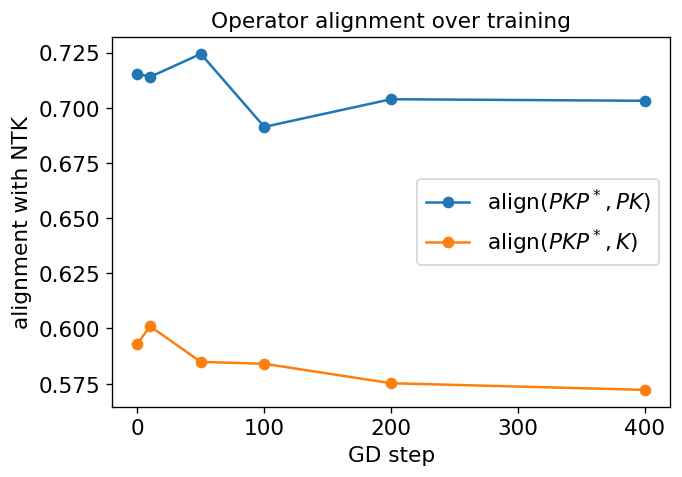

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df.step, df.ntk_align_pk, marker='o', label=r'$\mathrm{align}(PKP^*, PK)$')
ax.plot(df.step, df.ntk_align_k, marker='o', label=r'$\mathrm{align}(PKP^*, K)$')
ax.set_xlabel('GD step')
ax.set_ylabel('alignment with NTK')
ax.legend()
ax.set_title('Operator alignment over training')
plt.show()

# Verify NTK is truly equal to $P K P^*$, as in my paper, measuring max relative error over all snapshots:

In [28]:
print("max factorization error:", df.ntk_fact_compare.max())
df

max factorization error: tensor(5.1677e-08, device='cuda:0')


,step,ntk_fact_compare,ntk_align_ntk_fact,ntk_align_pk,ntk_align_k
0,0,"tensor(5.1677e-08, device='cuda:0')",1.0,0.715423,0.593153
1,10,"tensor(4.5403e-08, device='cuda:0')",1.0,0.713955,0.600962
2,50,"tensor(0., device='cuda:0')",1.0,0.724382,0.584831
3,100,"tensor(0., device='cuda:0')",1.0,0.691312,0.583994
4,200,"tensor(4.6877e-08, device='cuda:0')",1.0,0.703834,0.575168
5,400,"tensor(5.0209e-08, device='cuda:0')",1.0,0.703129,0.572165
